In [40]:
import os
import pandas as pd
import numpy as np
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [41]:
# Load saved training data
X_train = np.load("../models/X_train.npy")
X_test = np.load("../models/X_test.npy")
y_train = np.load("../models/y_train.npy")
y_test = np.load("../models/y_test.npy")
target_encoder = joblib.load("../models/target_encoder.pkl")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (12000, 20)
X_test shape: (3000, 20)


In [42]:
# Reshape for LSTM (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)

X_train_lstm shape: (12000, 1, 20)
X_test_lstm shape: (3000, 1, 20)


In [43]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=False,
        input_shape=(1, X_train_lstm.shape[2])
    )
)

model.add(Dropout(0.3))
model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(3, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
history = model.fit(
    X_train_lstm,
    y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6564 - loss: 0.7766 - val_accuracy: 0.6308 - val_loss: 0.7835
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7709 - loss: 0.5237 - val_accuracy: 0.7792 - val_loss: 0.5416
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8057 - loss: 0.4452 - val_accuracy: 0.8525 - val_loss: 0.3546
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8202 - loss: 0.4142 - val_accuracy: 0.8625 - val_loss: 0.3095
Epoch 5/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8310 - loss: 0.3881 - val_accuracy: 0.8604 - val_loss: 0.3003
Epoch 6/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8367 - loss: 0.3766 - val_accuracy: 0.8608 - val_loss: 0.3037
Epoch 7/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8432 - loss: 0.3549 - val_accuracy: 0.8671 - val_loss: 0.2856
Epoch 8/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8403 - loss: 0.3552 - val_accuracy: 0.

In [45]:
pred = model.predict(X_test_lstm)
lstm_pred = np.argmax(pred, axis=1)

acc = accuracy_score(y_test, lstm_pred)
print("LSTM Accuracy:", acc)
print(classification_report(y_test, lstm_pred, target_names=target_encoder.classes_))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
LSTM Accuracy: 0.885
              precision    recall  f1-score   support

        High       0.85      0.85      0.85       798
         Low       0.93      0.91      0.92       716
      Medium       0.88      0.89      0.88      1486

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



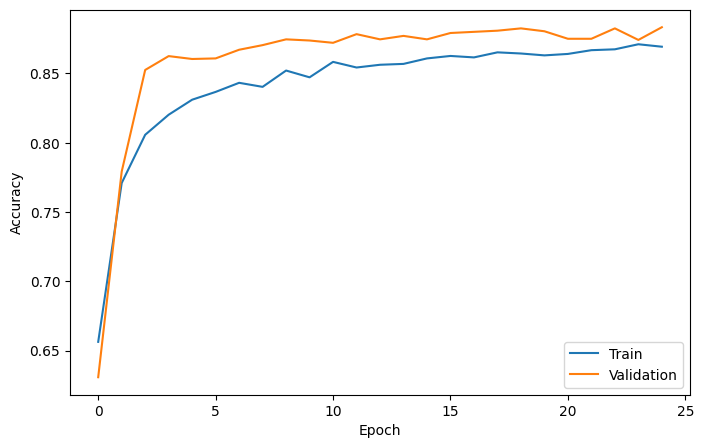

In [46]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [47]:
os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_model.keras")
print("LSTM model saved.")

LSTM model saved.
